# UMAP clustering of FORUM ranking policies

This notebook treats each of the **90 FORUM policy bundles** as one point: 15 orderings (including random) × 3 reply modes × 2 pin states. A point is represented by its story-averaged FORUM values on the 41 scalar features used by the regression/ML ranking models.

The notebook compares two raw spaces—**top 10** and **full list**—using UMAP embeddings and HDBSCAN clustering. It reads the already-calculated FORUM values from the FORUM policy-score product; it does not recalculate rankings or FORUM trajectories.

Raw BGE dimensions and the newer FORUM policy outcomes are excluded. The analysis deliberately starts with unstandardized FORUM axes.

In [1]:
from pathlib import Path
import json

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap
from IPython.display import display
from sklearn.cluster import HDBSCAN

from commentgap_analysis.forum_scores import REGRESSION_FEATURE_COLUMNS
from commentgap_analysis.ranking_similarity_plotting import plot_umap_clusters
from commentgap_analysis.presentation_labels import (
    ORDERING_DISPLAY_COLORS, ORDERING_DISPLAY_LABELS, ORDERING_DISPLAY_ORDER,
    OUTCOME_DISPLAY_ORDER,
    REPLY_DISPLAY_MARKERS,
)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'commentgap_analysis').exists() and (REPO_ROOT.parent / 'commentgap_analysis').exists():
    REPO_ROOT = REPO_ROOT.parent
SCORES_PATH = REPO_ROOT / 'model_output/selection_2025/forum_ranking_analysis/policy_scores/policy_scores.parquet'
OUTPUT_ROOT = REPO_ROOT / 'model_output/selection_2025/ranking_policy_similarity'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Main analysis configuration.
FEATURE_SPACE = 'regression'  # 'regression' or 'forum'
STANDARDIZE = False           # z-score each selected feature across policy bundles
if FEATURE_SPACE not in {'regression', 'forum'}:
    raise ValueError("FEATURE_SPACE must be 'regression' or 'forum'.")
FEATURES = list(REGRESSION_FEATURE_COLUMNS if FEATURE_SPACE == 'regression' else OUTCOME_DISPLAY_ORDER)
SPACE_LABEL = 'regression features' if FEATURE_SPACE == 'regression' else 'FORUM outcomes'
SCALE_LABEL = 'standardized' if STANDARDIZE else 'unstandardized'

DEPTHS = ('top10', 'full')
MAX_K = 12
USER_CLUSTER_K = {'top10': None, 'full': None}  # Optional manual overrides.
print(f'{len(FEATURES)} {SPACE_LABEL}; {SCALE_LABEL}')

41 regression features; unstandardized


## Sample and existing FORUM product

In the FORUM code, the **primary sample** means every eligible discussion with at least 11 comments. The separate large-thread sensitivity subset requires at least 100 comments. Here both top-10 and full-list spaces use all eligible scored discussions; neither depth is treated as a sensitivity analysis.

DuckDB filters and aggregates the existing Parquet product before moving data into pandas. The expected result is only 90 × 12 × 2 rows.

In [2]:
if not SCORES_PATH.exists():
    raise FileNotFoundError(SCORES_PATH)
from commentgap_analysis.forum_scores import FORUM_ANALYSIS_VERSION
score_manifest_path = SCORES_PATH.parent / 'policy_score_manifest.json'
if not score_manifest_path.exists() or json.loads(score_manifest_path.read_text()).get('version') != FORUM_ANALYSIS_VERSION:
    raise RuntimeError('Stale pin/reply semantics. Rerun notebook 10 before notebook 13.')
# Aggregate the current scores; shape-only CSV caches cannot establish provenance.
expected_rows = 90 * len(FEATURES) * len(DEPTHS)
feature_sql = ', '.join("'" + feature.replace("'", "''") + "'" for feature in FEATURES)
scores_sql_path = str(SCORES_PATH).replace("'", "''")
query = f'''
SELECT policy_id, ordering, reply_mode, pinned, deployable, outcome, depth,
       AVG(forum) AS mean_forum, COUNT(DISTINCT story_id) AS n_stories
FROM read_parquet('{scores_sql_path}')
WHERE outcome IN ({feature_sql}) AND depth IN ('top10', 'full')
GROUP BY policy_id, ordering, reply_mode, pinned, deployable, outcome, depth
ORDER BY depth, policy_id, outcome
'''
feature_means = duckdb.sql(query).df()

if len(feature_means) != expected_rows:
    raise ValueError(f'Expected {expected_rows:,} aggregated rows, found {len(feature_means):,}.')
if feature_means.policy_id.nunique() != 90:
    raise ValueError('The policy product does not contain all 90 policy bundles.')
if set(feature_means.outcome) != set(FEATURES):
    raise ValueError(f'The available axes do not match the selected {SPACE_LABEL}.')
coverage = feature_means.groupby(['depth', 'policy_id', 'outcome']).n_stories.first()
if coverage.nunique() != 1:
    raise ValueError('Policy-feature cells do not have identical story coverage.')

policy_metadata = feature_means[
    ['policy_id', 'ordering', 'reply_mode', 'pinned', 'deployable']
].drop_duplicates().sort_values('policy_id').reset_index(drop=True)
policy_metadata['pin_state'] = np.where(policy_metadata.pinned, 'pinned', 'unpinned')
policy_metadata['interface'] = policy_metadata.reply_mode + ' · ' + policy_metadata.pin_state

display(policy_metadata.groupby(['ordering', 'reply_mode', 'pinned'], dropna=False).size().to_frame('bundles'))
print(f"{feature_means.policy_id.nunique()} bundles; {feature_means.outcome.nunique()} axes; "
      f"{int(coverage.iloc[0]):,} stories per policy-feature-depth cell.")

bundles
ordering                 reply_mode pinned         
chronological            hidden     False         1
                                    True          1
                         loose      False         1
                                    True          1
                         trees      False         1
...                                             ...
xgb_metadata_text_editor hidden     True          1
                         loose      False         1
                                    True          1
                         trees      False         1
                                    True          1

[90 rows x 1 columns]

90 bundles; 41 axes; 2,556 stories per policy-feature-depth cell.


## Construct the two raw FORUM spaces

Rows are policy bundles and columns are model features. Values are article-weighted mean FORUM scores. No z-scoring or variance rescaling is applied. Because every FORUM axis has the same theoretical range, Euclidean distance has a direct interpretation here—but features with more observed cross-policy variation will contribute more to distance.

In [3]:
matrices = {}
for depth in DEPTHS:
    matrix = feature_means[feature_means.depth.eq(depth)].pivot(
        index='policy_id', columns='outcome', values='mean_forum'
    )
    matrix = matrix.reindex(index=policy_metadata.policy_id, columns=FEATURES)
    if matrix.isna().any().any() or matrix.shape != (90, len(FEATURES)):
        raise ValueError(f'Incomplete {depth} FORUM matrix: {matrix.shape}')
    matrices[depth] = matrix

if STANDARDIZE:
    matrices = {depth: (matrix - matrix.mean()) / matrix.std(ddof=1) for depth, matrix in matrices.items()}

print('Matrix shapes:', {depth: matrix.shape for depth, matrix in matrices.items()})


Matrix shapes: {'top10': (90, 41), 'full': (90, 41)}


## UMAP clustering (primary analysis)

Each raw space is clustered once using a 10-dimensional UMAP embedding and HDBSCAN with fixed defaults. A separate 2-dimensional UMAP embedding is used only to display those cluster labels; it is not reclustered. The plot is the primary result of this notebook.

/home/patrick/Documents/commentgap/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP-HDBSCAN cluster sizes:


/home/patrick/Documents/commentgap/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/home/patrick/Documents/commentgap/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/patrick/Documents/commentgap/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


bundles  orderings           reply_modes  pinned_bundles
depth umap_cluster                                                          
full  -1                  4          2                 loose               2
       0                 14          7                hidden               7
       1                 20         10                 loose              10
       2                  8          4                hidden               4
       3                  8          4                hidden               4
       4                 11         11                 trees               0
       5                 13         11          loose, trees              12
       6                 12          4          loose, trees               6
top10  0                 32         15  hidden, loose, trees              25
       1                 18         15  hidden, loose, trees               0
       2                 22         10         hidden, loose              20
       3                 18          9         hidden, loose               0

/home/patrick/Documents/commentgap/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/patrick/Documents/commentgap/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


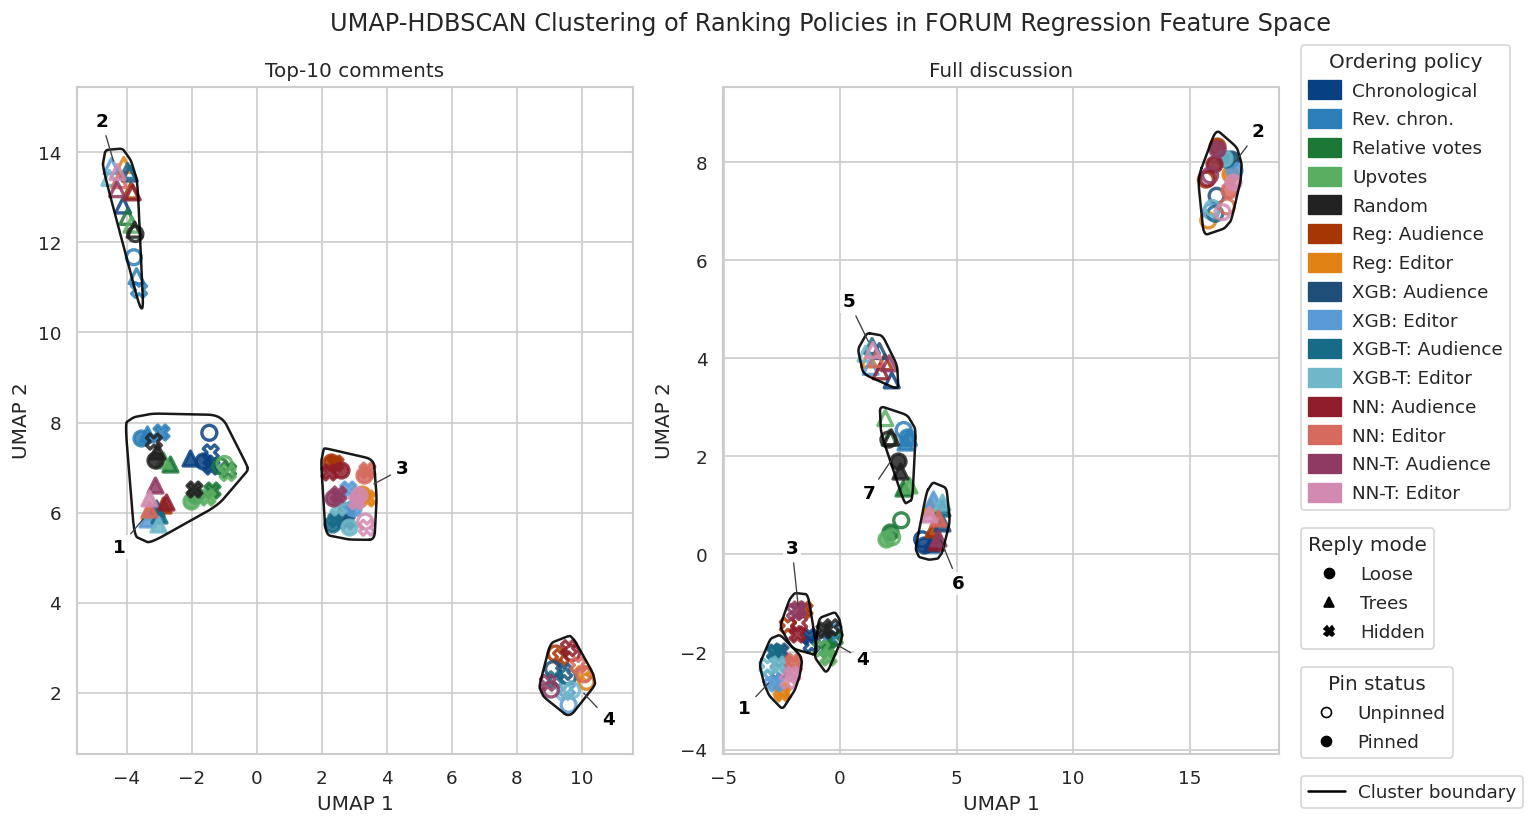

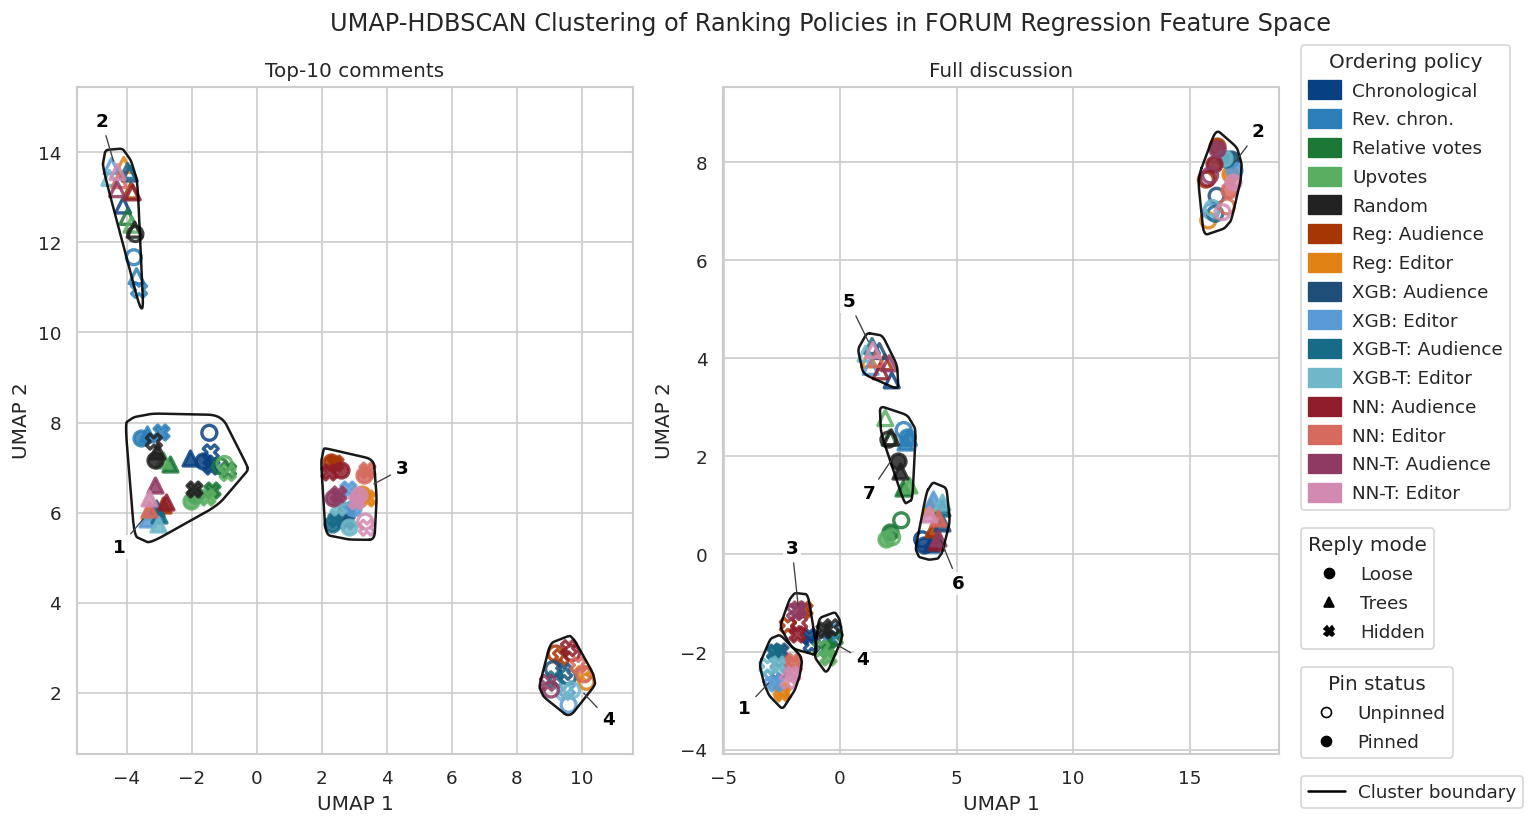

In [4]:
umap_cluster_parts = []
reply_markers = REPLY_DISPLAY_MARKERS
reply_labels = {'loose': 'Loose', 'trees': 'Trees', 'hidden': 'Hidden'}

for depth in DEPTHS:
    cluster_embedding = umap.UMAP(
        n_components=10, n_neighbors=15, min_dist=0.0,
        metric='euclidean', random_state=20260902,
    ).fit_transform(matrices[depth])
    cluster_labels = HDBSCAN(
        min_cluster_size=6, min_samples=3,
        cluster_selection_method='eom',
    ).fit_predict(cluster_embedding)
    frame = policy_metadata.copy()
    frame['depth'] = depth
    frame['umap_cluster'] = cluster_labels
    umap_cluster_parts.append(frame)

umap_cluster_membership = pd.concat(umap_cluster_parts, ignore_index=True)
print('UMAP-HDBSCAN cluster sizes:')
display(umap_cluster_membership.groupby(['depth', 'umap_cluster']).agg(
    bundles=('policy_id', 'size'), orderings=('ordering', 'nunique'),
    reply_modes=('reply_mode', lambda values: ', '.join(sorted(set(values)))),
    pinned_bundles=('pinned', 'sum'),
))

umap_cluster_order = sorted(umap_cluster_membership['umap_cluster'].unique())
umap_cluster_ids = [cluster for cluster in umap_cluster_order if cluster != -1]
# Keep the boundary visibly clear of the largest point markers.
CLUSTER_BOUNDARY_PADDING = 0.4
# Add a panel-scale floor so compact clusters do not collapse onto their markers.
CLUSTER_MIN_GAP_FRACTION = 0.015
# Use shorter straight sections so the quadratic corners dominate the shape.
CLUSTER_CORNER_CUT = 0.2
available_orderings = set(policy_metadata['ordering'])
ordering_order = [ordering for ordering in ORDERING_DISPLAY_ORDER if ordering in available_orderings]
ordering_palette = {
    ordering: ORDERING_DISPLAY_COLORS.get(ordering, '#777777')
    for ordering in ordering_order
}
depth_titles = {
    'top10': 'Top-10 comments',
    'full': 'Full discussion',
}

plot_umap_clusters(
    matrices, umap_cluster_membership, DEPTHS, ordering_order,
    ordering_palette, ORDERING_DISPLAY_LABELS, OUTPUT_ROOT / 'raw_umap.png',
    reply_markers=reply_markers,
    cluster_boundary_padding=CLUSTER_BOUNDARY_PADDING,
    cluster_min_gap_fraction=CLUSTER_MIN_GAP_FRACTION,
    cluster_corner_cut=CLUSTER_CORNER_CUT,
    label_clusters=True,
)

In [5]:
feature_means.to_csv(OUTPUT_ROOT / 'policy_feature_mean_forum_outcomes.csv', index=False)
umap_cluster_membership.to_csv(OUTPUT_ROOT / 'umap_cluster_membership.csv', index=False)

for depth in DEPTHS:
    matrices[depth].to_csv(OUTPUT_ROOT / f'{depth}_raw_forum_matrix.csv')

figure_inventory = pd.DataFrame({
    'figure': [
        path.name for path in (OUTPUT_ROOT / 'raw_umap.png',)
        if path.exists()
    ]
})
display(figure_inventory)
print(f'{len(figure_inventory)} UMAP figure saved')


,figure
0,raw_umap.png


1 UMAP figure saved
